### Tarefa prática para os métodos de Interpolação Polinomial

Utilizando os valores tabelados abaixo, responda aos itens **a**, **b** e **c**.  
Considere, para os métodos, um número $N = 100$ de pontos entre o $x$ inicial e final.

#### Tabela de valores

| x     | -5  | -1  | 2   | 8   | 10  | 17  | 19  | 24  | 33  | 36  |
|-------|-----|-----|-----|-----|-----|-----|-----|-----|-----|-----|
| f(x)  | 2.1 | 8.4 | 15.7| 21.3| 17.6| 9.2 | 14.8| 20.5| 11.3| 4.6 |


In [65]:
import numpy as np
import matplotlib.pyplot as plt

xi = np.array([-5, -1, 2, 8, 10, 17, 19, 24, 33, 36])
yi = np.array([2.1, 8.4, 15.7, 21.3, 17.6, 9.2, 14.8, 20.5, 11.3, 4.6])

In [66]:
def splines(xi, yi, x_alvo = None):
    n = len(xi)
    n_pontos = 100 #numero de pontos da malha
    
    # caso x_alvo exista, o algoritmo trata o x_alvo
    # como um vetor unico, entao ele será isolado do restante
    if x_alvo is not None:
        x = np.atleast_1d(x_alvo)
    else:
        x = np.linspace(xi[0], xi[-1], 100)

    n_eval = len(x)

    m = n - 1 #subintervalos
    h = np.zeros(n - 1)

    for i in range(n - 1):
        h[i] = xi[i + 1] - xi[i]

    a = yi
    A = np.zeros((n, n))
    r = np.zeros((n, 1))

    A[0, 0] = A[n - 1, n - 1] = 1

    for j in range(1, n - 1):
        A[j, j - 1] = h[j - 1]
        A[j, j] = 2 * h[j - 1] + h[j]
        A[j, j + 1] = h[j]
        r[j] = 3 * ((a[j + 1] - a[j]) / h[j] - (a[j] - a[j - 1]) / h[j - 1])

    c = np.linalg.solve(A, r)

    d = np.zeros((m, 1))
    b = np.zeros((m, 1))

    for j in range(m):
        d[j] = (c[j + 1] - c[j]) / (3 * h[j])
        b[j] = (a[j + 1] - a[j]) / h[j] - h[j] / 3 * (2 * c[j] + c[j + 1])

    y = np.zeros(n_eval)

    for k in range(n_eval):
        idx = m
        for j in range(m):
            if x[k] <= xi[j + 1]:
                idx = j
                break
        t = x[k] - xi[idx]
        y[k] = a[idx] + b[idx] * t + c[idx] * t ** 2 + d[idx] * t ** 3

    return x, y

In [67]:
def newton(xi, yi, x_alvo = None):
    n = len(xi)
    n_pontos = 100
    
    # caso x_alvo exista, o algoritmo trata o x_alvo
    # como um vetor unico, entao ele será isolado do restante
    if x_alvo is not None:
        x = np.atleast_1d(x_alvo)
    else:
        x = np.linspace(xi[0], xi[-1], 100)

    n_eval = len(x)

    D = np.zeros((n, n))

    D[:, 0] = yi
    for j in range(1, n):
        for i in range(j, n):
            D[i, j] = (D[i, j - 1] - D[i - 1, j - 1]) / (xi[i] - xi[i - j])

    c = np.diag(D)
    y = np.ones(n_eval) * c[0]
    xv = np.ones(n_eval)

    for j in range(1, n):
        xv *= (x - xi[j - 1])
        y += c[j] * xv

    return x, y

In [68]:
def lagrange(xi, yi, x_alvo = None):
    n = len(xi)
    n_pontos = 100 #numero de pontos da malha

    # caso x_alvo exista, o algoritmo trata o x_alvo
    # como um vetor unico, entao ele será isolado do restante
    if x_alvo is not None:
        x = np.atleast_1d(x_alvo)
    else:
        x = np.linspace(xi[0], xi[-1], 100)

    n_eval = len(x)

    L = np.ones((n, n_eval))

    for i in range(n):
        for j in range(n):
            if i != j:
                L[i, :] *= ((x - xi[j]) / (xi[i] - xi[j]))

    y = yi @ L
    return x, y

#### (a)
Determine o valor aproximado de $f(22)$ utilizando os interpoladores:
- Lagrange  
- Newton  
- Spline Cúbico Natural  

In [69]:
x_lag, y_lag = lagrange(xi, yi, 22)
print(y_lag)
x_new, y_new = newton(xi, yi, 22)
print(y_new)
x_spl, y_spl = splines(xi, yi, 22)
print(y_spl)

[22.59697573]
[22.59697573]
[20.5359465]


C:\Users\Vinícius Mardegan\AppData\Local\Temp\ipykernel_18324\1721194515.py:50: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  y[k] = a[idx] + b[idx] * t + c[idx] * t ** 2 + d[idx] * t ** 3


#### (b)
Plote, em um mesmo gráfico, as curvas geradas pelos três interpoladores:
- Lagrange  
- Newton  
- Spline Cúbico Natural  

no intervalo $[-5, 36]$ e compare as curvas obtidas.

C:\Users\Vinícius Mardegan\AppData\Local\Temp\ipykernel_18324\1721194515.py:50: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  y[k] = a[idx] + b[idx] * t + c[idx] * t ** 2 + d[idx] * t ** 3


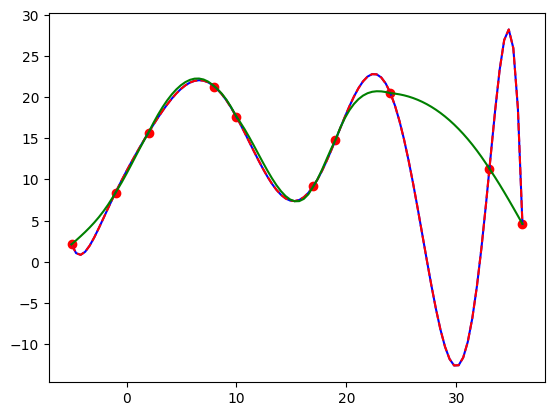

In [70]:
plt.plot(xi, yi, "ro")

x_lag, y_lag = lagrange(xi, yi)
plt.plot(x_lag, y_lag, "b-")

x_new, y_new = newton(xi, yi)
plt.plot(x_new, y_new, "r--")

x_spl, y_spl = splines(xi, yi)
plt.plot(x_spl, y_spl, "g-")


#### (c)
Utilizando cada curva gerada pelos interpoladores, determine:
- o valor **máximo** de $f(x)$
- o valor **mínimo** de $f(x)$

no intervalo $[-5, 36]$.

In [71]:
max_lag = np.argmax(y_lag)
min_lag = np.argmin(y_lag)

print(f"Ponto Minimo: ({x_lag[min_lag]}, {y_lag[min_lag]})")
print(f"Ponto Maximo: ({x_lag[max_lag]}, {y_lag[max_lag]})")

max_new = np.argmax(y_new)
min_new = np.argmin(y_new)

print(f"Ponto Minimo: ({x_new[min_new]}, {y_new[min_new]})")
print(f"Ponto Maximo: ({x_new[max_new]}, {y_new[max_new]})")

max_spl = np.argmax(y_spl)
min_spl = np.argmin(y_spl)

print(f"Ponto Minimo: ({x_spl[min_spl]}, {y_spl[min_spl]})")
print(f"Ponto Maximo: ({x_spl[max_spl]}, {y_spl[max_spl]})")

Ponto Minimo: (29.78787878787879, -12.62882000045959)
Ponto Maximo: (34.75757575757576, 28.247088553253946)
Ponto Minimo: (29.78787878787879, -12.628820000459406)
Ponto Maximo: (34.75757575757576, 28.247088553254002)
Ponto Minimo: (-5.0, 2.1)
Ponto Maximo: (6.595959595959595, 22.279388397178714)
